<a href="https://colab.research.google.com/github/sekhahelina/ML_tasks/blob/main/Module2/HW_2_4_kNN_%D0%9A%D1%80%D0%BE%D1%81%D0%B2%D0%B0%D0%BB%D1%96%D0%B4%D0%B0%D1%86%D1%96%D1%8F_%D1%96_%D1%82%D1%8E%D0%BD%D0%B8%D0%BD%D0%B3_%D0%B3%D1%96%D0%BF%D0%B5%D1%80%D0%BF%D0%B0%D1%80%D0%B0%D0%BC%D0%B5%D1%82%D1%80%D1%96%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from process_bank_churn import preprocess_data
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
raw_df = pd.read_csv("/content/drive/MyDrive/dataframes/Bank/train.csv", index_col=0)
data = preprocess_data(raw_df, scale_numeric=False)
(
    X_train,
    train_targets,
    X_val,
    val_targets,
    input_cols,
    scaler,
    encoder,
    numeric_imputer,
    categorical_imputer
) = preprocess_data(raw_df, False)

1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [7]:
knn = KNeighborsClassifier()
knn.fit(X_train, train_targets)

KNeighborsClassifier()

In [22]:
knn.feature_names_in_

array(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Geography_France', 'Geography_Germany', 'Geography_Spain',
       'Gender_Female', 'Gender_Male'], dtype=object)

In [24]:
def compute_auroc_and_build_roc(model, inputs, targets, name='', plot: bool = True):
  # Predict probabilities
  probs = model.predict_proba(inputs)[:, 1]
  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, probs)
  # Compute AUROC
  roc_auc = auc(fpr, tpr)

  print(f'AUROC for {name}: {roc_auc:.2f}')

  if plot:
        plt.figure(figsize=(6, 4))
        plt.plot(
            fpr,
            tpr,
            color='darkorange',
            lw=2,
            label=f'ROC curve (AUC = {roc_auc:.2f})'
        )
        plt.plot([0, 1], [0, 1], linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve ({name})')
        plt.legend(loc='lower right')
        plt.show()

  return

AUROC for training: 0.82


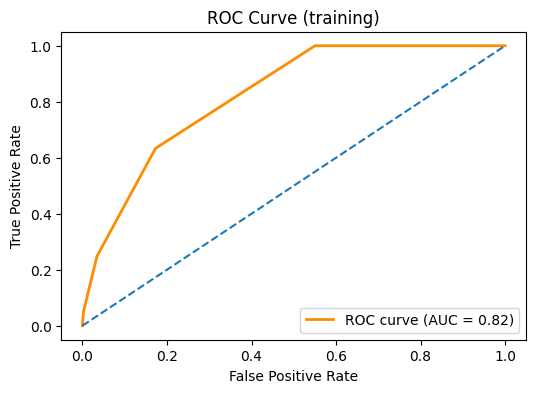

AUROC for Validation: 0.57


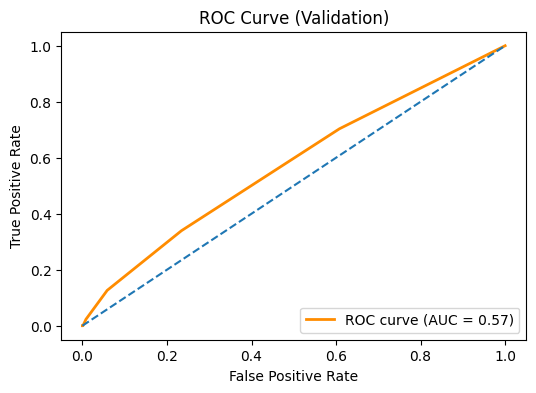

In [26]:
compute_auroc_and_build_roc(knn, X_train, train_targets, name='training')
compute_auroc_and_build_roc(knn, X_val, val_targets, name='Validation')

За результатами видно, що модель KNN значно краще працює на тренувальних даних, ніж на валідаційних. Метрика AUROC for training: 0.82, а для Validation: 0.57. Такий розрив свідчить про перенавчання моделі. Отже, можна зробити висновок що наша модель має high variance і low bias.

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [35]:
knn = KNeighborsClassifier()
params_knn = {'n_neighbors': np.arange(1, 25)}
knn_gs = GridSearchCV(knn, params_knn, cv=5)
knn_gs.fit(X_train, train_targets)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])})

In [36]:
knn_best = knn_gs.best_estimator_
knn_best

KNeighborsClassifier(n_neighbors=np.int64(24))

AUROC for training: 0.69


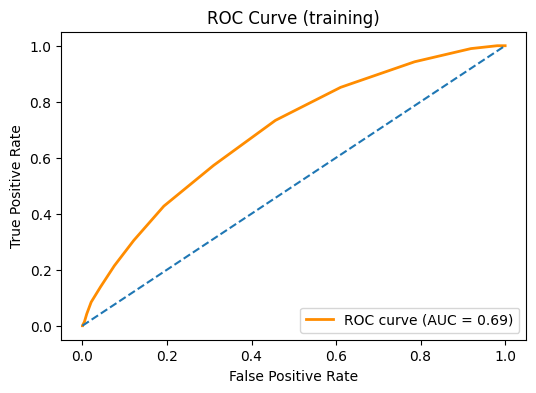

AUROC for Validation: 0.61


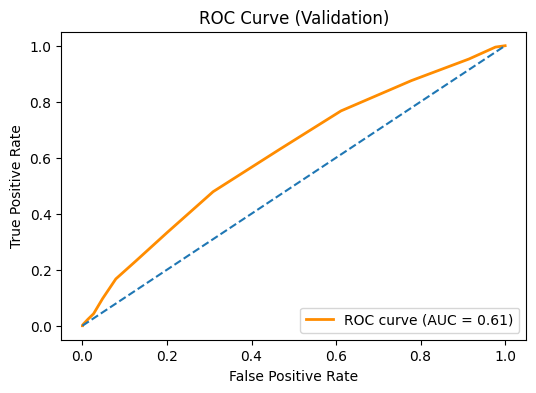

In [37]:
compute_auroc_and_build_roc(knn_best, X_train, train_targets, name='training')
compute_auroc_and_build_roc(knn_best, X_val, val_targets, name='Validation')

Тепер у нашої моделі відсутні ознаки перенавчання, але можна сказати що результати не є достатньо високими. AUROC for Validation збільшився і дорівнює 0.61, проте це не високий результат. У попередній роботі модель з деревом рішень дала кращий результат.

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [77]:
%%time

tree_model = DecisionTreeClassifier(random_state = 42)
params_tree = {
              'max_depth': np.arange(1, 20, 2),
              'max_leaf_nodes': np.arange(2, 10, 1)
              }
tree_gs = GridSearchCV(tree_model, params_tree, scoring='roc_auc', cv=3)
tree_gs.fit(X_train, train_targets)

CPU times: user 5.4 s, sys: 9.36 ms, total: 5.41 s
Wall time: 5.48 s


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                         'max_leaf_nodes': array([2, 3, 4, 5, 6, 7, 8, 9])},
             scoring='roc_auc')

In [78]:
tree_gs.best_params_

{'max_depth': np.int64(5), 'max_leaf_nodes': np.int64(9)}

In [79]:
dt_best = tree_gs.best_estimator_
dt_best

DecisionTreeClassifier(max_depth=np.int64(5), max_leaf_nodes=np.int64(9),
                       random_state=42)

AUROC for training: 0.90


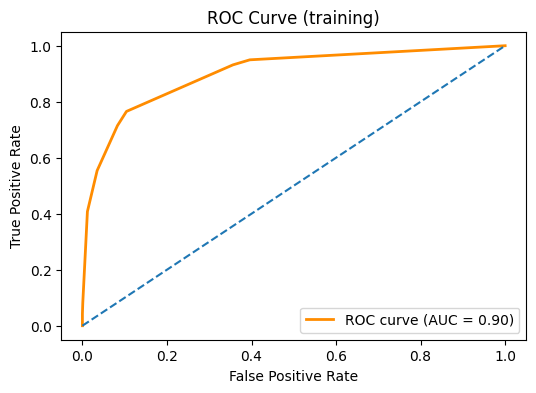

AUROC for Validation: 0.90


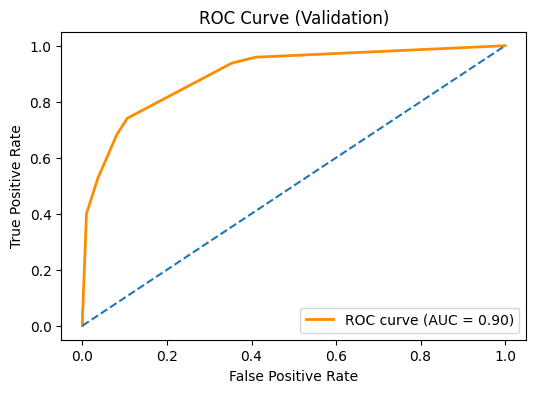

In [80]:
compute_auroc_and_build_roc(dt_best, X_train, train_targets, name='training')
compute_auroc_and_build_roc(dt_best, X_val, val_targets, name='Validation')

Ця модель набагато краща за попередні але при пошуку гіперпараметра min_samples_leaf були встановлені межі від 2 до 10. У минулій роботі результати метрик були кращі, адже було виявлено що найкращі метрики при min_samples_leaf = 28. Якщо змінити діапазон від 2 до 30 з кроком 2, то отримаємо результати метрик 0.93.

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [70]:
%%time
tree_model_r = DecisionTreeClassifier(random_state=42)
params_dtr = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 30),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}
tree_rs = RandomizedSearchCV (tree_model, params_tree, scoring='roc_auc', cv=3, random_state = 42)
tree_rs.fit(X_train, train_targets)

CPU times: user 663 ms, sys: 0 ns, total: 663 ms
Wall time: 736 ms


RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
                   param_distributions={'max_depth': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                                        'max_leaf_nodes': array([2, 3, 4, 5, 6, 7, 8, 9])},
                   random_state=42, scoring='roc_auc')

In [71]:
dt_random_search_best = tree_rs.best_estimator_
dt_random_search_best

DecisionTreeClassifier(max_depth=np.int64(7), max_leaf_nodes=np.int64(9),
                       random_state=42)

In [72]:
compute_auroc_and_build_roc(dt_random_search_best, X_train, train_targets, name='training', plot = False)
compute_auroc_and_build_roc(dt_random_search_best, X_val, val_targets, name='Validation', plot = False)

AUROC for training: 0.90
AUROC for Validation: 0.90


Після проведених експериментів можна побачити, що обидва підходи продемонстрували однакові значення метрик, проте знайдені оптимальні гіперпараметри дещо відрізняються. GridSearch визначив оптимальне значення max_depth = 5, тоді як RandomizedSearch - max_depth = 7. Однак ця різниця не мала впливу на якість моделі. Оскільки було відомо, що найкращий результат досягається при min_samples_leaf = 28, я провела додатковий експеримент, розширивши діапазони пошуку для обох методів. У результаті GridSearch знайшов оптимальне значення, що призвело до покращення метрик, тоді як RandomizedSearch такого результату не досяг.

5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

Оскільки в результаті мої метрики не покращились відносно попередньої роботи, вирішила не робити submission.